In [16]:
# --------------------------
# Import bibliotek
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [17]:
# --------------------------
# Wczytanie danych
# --------------------------
df = pd.read_csv("titanic.csv")
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')
print("Rozmiar danych:", df.shape)
print(df.head())

Rozmiar danych: (1309, 14)
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    ?   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    ?   
2   2.0000      1      2  113781  151.5500  C22 C26        S    ?    ?   
3  30.0000      1      2  113781  151.5500  C22 C26        S    ?  135   
4  25.0000      1      2  113781  151.5500  C22 C26        S    ?    ?   

                         home.dest  
0         


Braki danych w kolumnach:
 pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin          0
embarked       0
boat           0
body           0
home.dest      0
dtype: int64


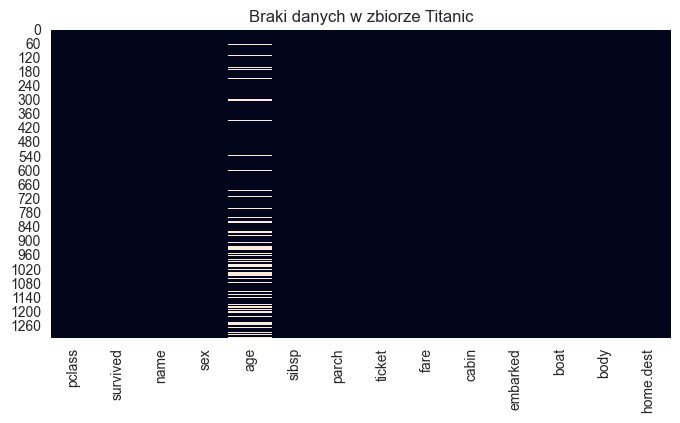

In [18]:
# --------------------------
# Analiza braków danych
# --------------------------
missing = df.isna().sum()
print("\nBraki danych w kolumnach:\n", missing)

plt.figure(figsize=(8,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Braki danych w zbiorze Titanic")
plt.show()

In [19]:
# --------------------------
# Usunięcie kolumn z wyciekiem danych
# --------------------------
columns_to_drop = ['boat', 'body', 'ticket', 'cabin', 'home.dest']
df.drop(columns=columns_to_drop, inplace=True)

In [20]:
# --------------------------
# Feature engineering
# --------------------------
# Tytuł z imienia
def extract_title(name):
    return name.split(',')[1].split('.')[0].strip()
df['title'] = df['name'].apply(extract_title)

# Uzupełnianie wieku na podstawie tytułów
title_age_mean = df.groupby('title')['age'].mean()
def fill_age(row):
    if pd.isna(row['age']):
        if row['title'] in title_age_mean and not pd.isna(title_age_mean[row['title']]):
            return title_age_mean[row['title']]
        else:
            return df.loc[df['sex'] == row['sex'], 'age'].mean()
    return row['age']
df['age'] = df.apply(fill_age, axis=1)

# Wielkość rodziny
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Kategorie wiekowe
def age_range(age):
    if age < 6:
        return 'Bobas'
    elif age < 12:
        return 'Dzieciak'
    elif age < 18:
        return 'Nastolatek'
    else:
        return 'Dorosly'
df['age_range'] = df['age'].apply(age_range)

# MPC
df['mpc'] = df['age'] * df['pclass']

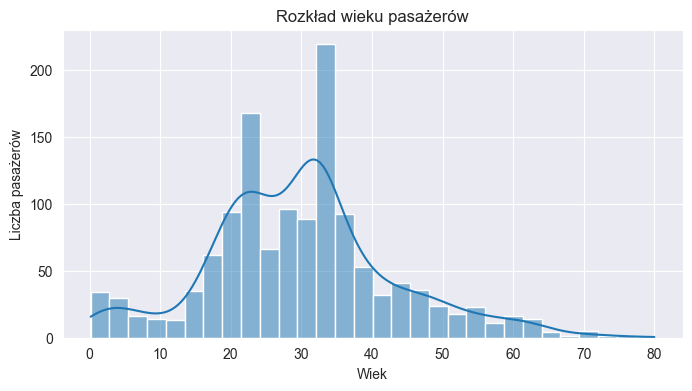

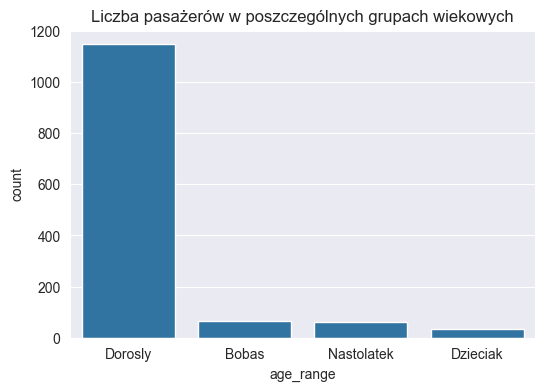

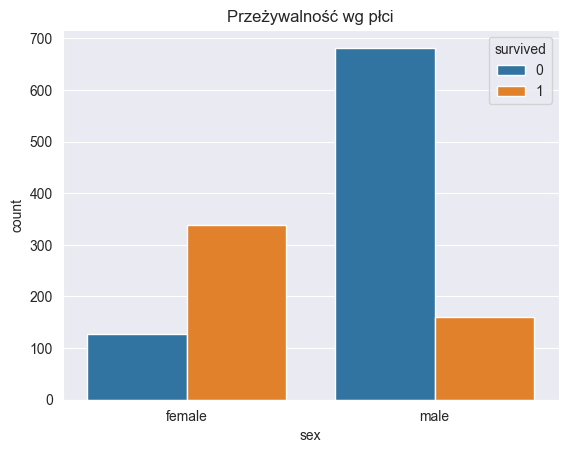

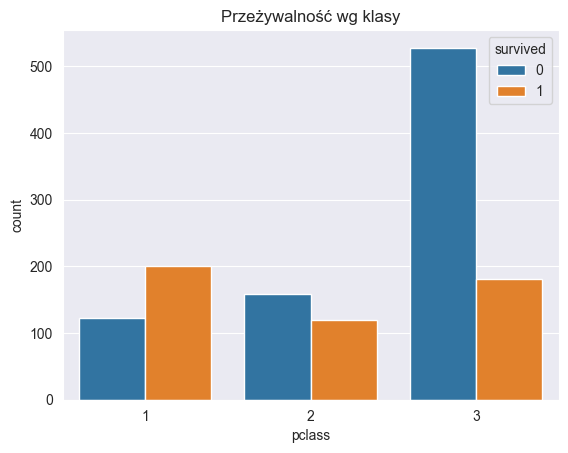

In [21]:
# --------------------------
# Podstawowe wizualizacje
# --------------------------
# Rozkład wieku
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Rozkład wieku pasażerów")
plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.show()

# Grupy wiekowe
plt.figure(figsize=(6,4))
sns.countplot(x='age_range', data=df)
plt.title("Liczba pasażerów w poszczególnych grupach wiekowych")
plt.show()

# Survival wg płci
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Przeżywalność wg płci")
plt.show()

# Survival wg klasy
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Przeżywalność wg klasy")
plt.show()

In [22]:
# --------------------------
# Konwersja typów danych
# --------------------------
categorical_cols = ['sex', 'embarked', 'age_range', 'pclass', 'title']
df[categorical_cols] = df[categorical_cols].astype('category')

In [23]:
# --------------------------
# Imputacja braków danych
# --------------------------
df['fare'] = df['fare'].fillna(df['fare'].median())
imputer = IterativeImputer(random_state=42)
df[['age', 'fare', 'mpc']] = imputer.fit_transform(df[['age', 'fare', 'mpc']])

# Przycinanie wartości odstających
df.loc[df['age'] > 67, 'age'] = 67
fare_cap = df['fare'].quantile(0.99)
df.loc[df['fare'] > fare_cap, 'fare'] = fare_cap

In [24]:
# --------------------------
# Kodowanie zmiennych kategorycznych
# --------------------------
df = pd.get_dummies(df, columns=['sex','pclass','age_range','title','embarked'], drop_first=False)

In [25]:
# --------------------------
# Normalizacja zmiennych numerycznych
# --------------------------
scaler = StandardScaler()
numeric_cols = ['age', 'fare', 'family_size', 'mpc']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

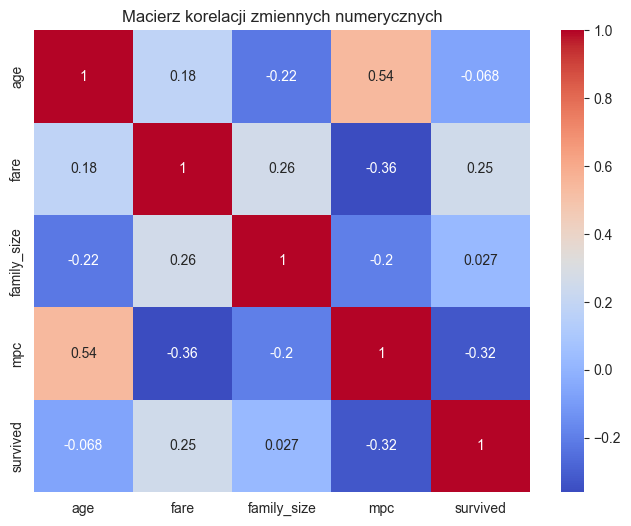

In [26]:
# --------------------------
# Korelacja zmiennych
# --------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols + ['survived']].corr(), annot=True, cmap='coolwarm')
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

In [27]:
# --------------------------
# Wybór cech predykcyjnych (maks 8) i zmiennej celu
# --------------------------
y = df['survived']
X = df[[
    'sex_male',
    'age',
    'fare',
    'family_size',
    'pclass_1',
    'pclass_3',
    'age_range_Bobas',
    'age_range_Dorosly'
]]

In [28]:
# --------------------------
# Podział danych na zbiór treningowy i testowy
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
# --------------------------
# Definicja modeli
# --------------------------
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)

In [30]:
# --------------------------
# Trenowanie i ewaluacja modeli
# --------------------------
# Logistic Regression
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))

# Decision Tree
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))

# Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression accuracy: 0.8435114503816794
Decision Tree accuracy: 0.8473282442748091
Random Forest accuracy: 0.8435114503816794

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88       162
           1       0.86      0.71      0.78       100

    accuracy                           0.84       262
   macro avg       0.85      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262

